In [1]:
 #defines function to convert .idx files to .csv files
def IndexToCSV(file,output=None, model=None, fps=10,video=1, unique_adj=False):
    """
    A function to convert the whole index file (excluding the header) to a csv

    Parameters
    ----------
    file : Str
        Input .idx file location
    output : Str
        Output .csv file location  
    model : pkl model
        The model used to create the state classifier. If not supplied,
        the basic thresholding will be used (1mm/sec=locomotive, <1mm/sec = Stationary,
        >10px Activity Level = Stationary Active, <10px Activity Level = Stationary Static)
    fps : int (default 10).
        The fps of the recording.
    video : int (0 or 1)
        To say if you had created movr files when doing the experiment. 
        Default is yes (1). If you hadnt, use (0)
    Returns
    -------
    CSV if no output supplied.
    
    Outputs
    -------
    CSV
    """
    
    import struct
    import pandas as pd
    import joblib
    
    
    input_file_name = (file)
    input_file = open(input_file_name, 'rb')

    input_file.read(1)
    data1=input_file.read(4)
    metrics_list_array_size=struct.unpack(">I", data1)
    input_file.read(2*metrics_list_array_size[0])
    data3=input_file.read(4)
    record_size=struct.unpack(">i",data3)

    if video==1:    
        xx=0  
        while (byte := input_file.read(1)): 
            xx=xx+1#The while is to skip past the next few bytes until it finds the .movr bytes
            if b'.' in byte:
                byte = input_file.read(4)
                xx=xx+4
                if byte==b'movr':
                    break
                else:
                    continue
            else:
                continue
    elif video==0:
        xx=0  
        while (byte := input_file.read(1)): 
            xx=xx+1#The while is to skip past the next few bytes until it finds the .movr bytes
            if b'V' in byte:
                byte = input_file.read(3)
                xx=xx+3
                if byte==b'OID':
                    break
                else:
                    continue
            else:
                continue
    input_file.read(8)
    input_file.read(8)
    data5=input_file.read(4)
    group_string_length = struct.unpack(">I", data5)

    input_file.read(group_string_length[0])
    if group_string_length[0] > 0:
        group_string=struct.unpack(">c", data5)
        print(group_string)
    data7=input_file.read(48)


    #reading bytes?
    import os
    size = os.path.getsize(input_file_name)
    s = size -(77+(2*metrics_list_array_size[0])+(group_string_length[0])+xx)   #Not sure if the xx will work for all cases.. in this case is 69
    record_length = s/record_size[0]

    cols = ['Record Number', 'Timestamp (ms)', 'State', 'Activity Level', 'Movr Frame', 'cXmm', 'Speed_Av_mm_per_sec', 'Heading_deg', 'cYmm', 'Error_code'] #Will need to change the metric names if they change
    lst = []
    
    from tqdm import tqdm
    for n in tqdm(range(0,int(record_length))):
        data7=input_file.read(4)
        ms_time=struct.unpack(">I", data7)

        data8=input_file.read(1)
        state=struct.unpack(">B",data8)
        if state[0] == 0:
            x="Unknown"
        elif state[0] == 1:
            x="Locomotive"
        elif state[0] == 2:
            x="Stationary"
        elif state[0]== 3:
            x="Stationary Static"
        elif state[0]==4:
            x="Stationary Active"
        else:
            raise ValueError("Unknown state value: {}".format(state[0]))

        data9 = input_file.read(2)
        activity_level=struct.unpack(">H",data9)

        data10 = input_file.read(4)
        movr_frame=struct.unpack(">I", data10)

        data11 = input_file.read(4)
        metrics_array_size=struct.unpack(">I", data11)

        data12 = input_file.read(4*metrics_array_size[0])
        a =">"+str(metrics_array_size[0])+"f"
        metrics_array=struct.unpack(a, data12)
        lst.append([n, ms_time[0], x, activity_level[0], movr_frame[0], metrics_array[0], metrics_array[1], metrics_array[2], metrics_array[3], metrics_array[4]])

    df1 = pd.DataFrame(lst, columns=cols)

    if unique_adj==True:
        df1['cXmm']=df1['cXmm'] * (1/68) * 6.4
        df1['cYmm']=df1['cYmm'] * (1/68) * 6.4
        df1['Speed_Av_mm_per_sec']=df1['Speed_Av_mm_per_sec'] * (1/68) * 6.4

    if model != None:
        nums=[1] if fps==10 else [1,2,3,4,5]
        for n in nums:
            df1['Activity Level_prior'+str(n)] = df1['Activity Level'].shift(n)
            df1['Speed_prior'+str(n)] = df1['Speed_Av_mm_per_sec'].shift(n)
        df1 = df1.dropna().copy()
        if fps == 10:
            y_pred = model.predict(df1.loc[:,('Speed_Av_mm_per_sec','Activity Level', 'Activity Level_prior1','Speed_prior1')])
        else:
            y_pred = model.predict(df1.loc[:,('Speed_Av_mm_per_sec','Activity Level', 'Activity Level_prior1','Speed_prior1','Activity Level_prior2','Speed_prior2','Activity Level_prior3','Speed_prior3','Activity Level_prior4','Speed_prior4','Activity Level_prior5','Speed_prior5')])
        df1['New_state'] = y_pred

        df1.loc[(df1['State'] =='Stationary Static'), ['Old_State']] = 1
        df1.loc[(df1['State'] =='Stationary Active'), ['Old_State']] = 2
        df1.loc[(df1['State'] =='Locomotive'), ['Old_State']] = 3

        df1=df1.loc[:,('Record Number','Timestamp (ms)','Movr Frame','Error_code','cXmm', 'cYmm','Heading_deg','Activity Level','Speed_Av_mm_per_sec','Old_State','New_state')].reset_index().copy()

    if output == None:
        return df1
    else:
        df1.to_csv(output)

In [2]:
# Defines function to convert all idx files in a folder to csv files in another folder. Just specify input and output folder paths in following cell.
def idx_to_csv(input, output):
    import os
    for filename in os.listdir(input):
        if filename.endswith(".idx") and not filename.startswith('._'):
            IndexToCSV(file = os.path.join(input, filename), model=None, fps=10,
                        output = os.path.join(output, filename.split(".")[0]+'.csv')
            )

In [96]:
import os

#Make sure to specify input and output paths here
input_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\alldata\\OK371 x GtCCR4 (EL)'
output_path = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\processed data\\OK371 x GtCCR4 (EL)'

# Creates your output folder if it does not exist
os.makedirs(output_path, exist_ok=True)

# Runs conversion from idx to csv
idx_to_csv(input=input_path, output=output_path)


100%|██████████| 1799/1799 [00:00<?, ?it/s]


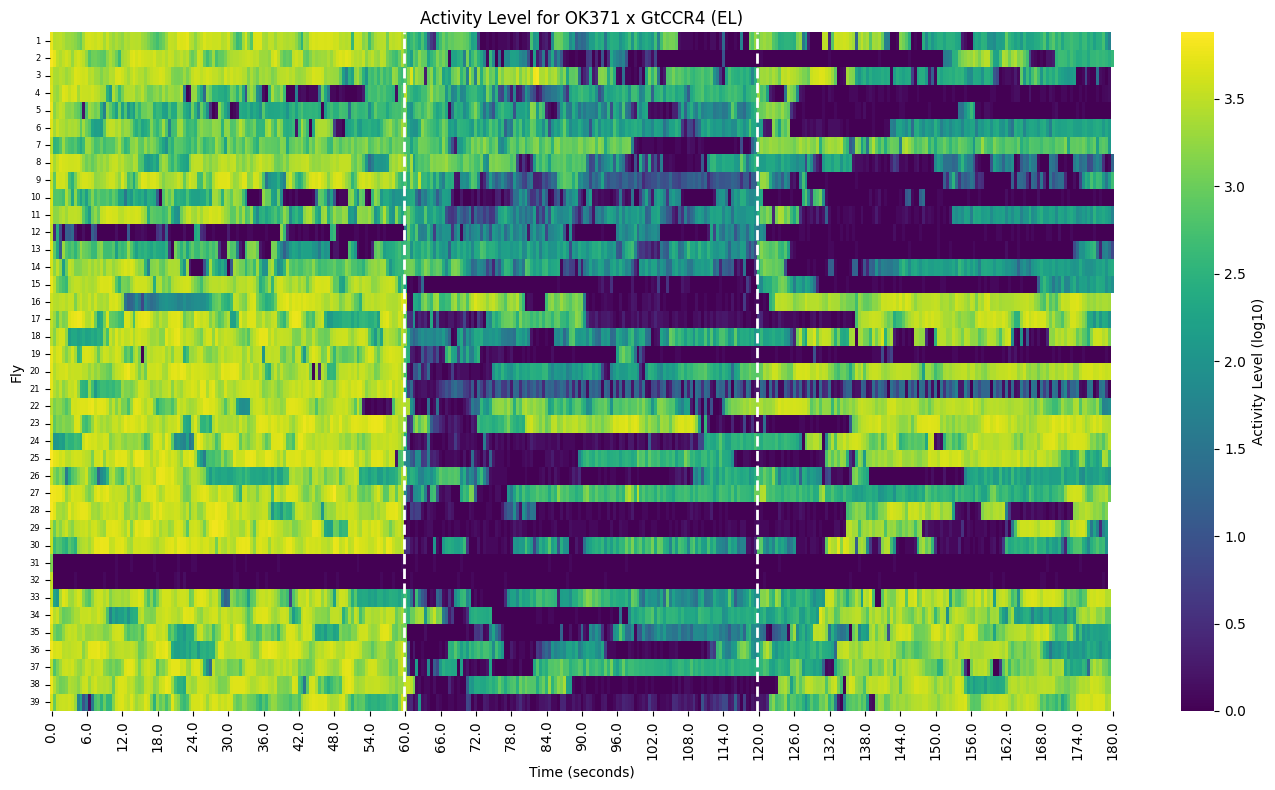

In [97]:
# Generates activity heatmap for a given cross, with Movr Frame resampled to 0.5s intervals and log scale applied
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os

# Define cross_folder_name (folder your data is in) and set base_path, to be used in title generation
cross_folder_name = "OK371 x GtCCR4 (EL)"

# Auto-generate folder path and chart title from cross_name
base_path = "C:\\Users\\Leif_D\\Documents\\trumelan data\\chrmine_gtccr4\\processed data"
folder_path = os.path.join(base_path, cross_folder_name)

# Tweak title generation to extract title properly from your filename structure, or just comment out parts, main and extra, then set it manually (probably easier).
# parts = cross_folder_name.replace('_', ' ').split()
# main = ' > '.join(parts[:2])
# extra = ' '.join(p for p in parts[2:] if 'csv' not in p.lower())
title_name = "Activity Level for OK371 x GtCCR4 (EL)" #if extra else f"Activity Level for {main} (log scale, 60-65s illumination)"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

data_list = []


# Load each fly's data, synchronize timestamps to start at 0s, and keep only Activity Level
for i, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file, usecols=["Timestamp (ms)", "Activity Level"])
    # Convert Timestamp to seconds and start at 0
    df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000
    df = df.set_index("Time (s)")
    df = df[[ "Activity Level" ]]  # keep only activity
    df.rename(columns={"Activity Level": f"{i}"}, inplace=True)
    data_list.append(df)

# Combine all flies into one dataframe
all_data = pd.concat(data_list, axis=1)

# Limit to however many seconds you'd like
all_data = all_data[all_data.index <= 180]

# Resample to .5-second intervals (mean per bin). Can adjust bin size here.
bin_size = .5
all_data_resampled = all_data.groupby((all_data.index // bin_size) * bin_size).mean()

# Log transform (avoid log(0))
all_data_log = np.log10(all_data_resampled + 1)

# Transpose for heatmap: rows = flies, columns = time bins
heatmap_data = all_data_log.T

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    cbar_kws={'label': 'Activity Level (log10)'},
    xticklabels=12,  # show every 12th label to reduce clutter
    yticklabels=True
)

#Set font size
plt.yticks(fontsize=6)


# Demarcates illumination period with dashed white vertical lines
illum_start, illum_end = 60, 120
illum_start_idx = int(illum_start // bin_size)
illum_end_idx = int(illum_end // bin_size)
plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

# Express x-axis in minutes while keeping internal data in seconds
# tick_positions = plt.xticks()[0]
# tick_labels = [
#     str(int(val)) if val.is_integer() else f"{val:.0f}"
#     for val in [(pos * bin_size) / 60 for pos in tick_positions]
# ]
# plt.xticks(tick_positions, tick_labels)

plt.xlabel("Time (seconds)")
plt.ylabel("Fly")
plt.title(title_name)
plt.tight_layout()

output_path_img = 'C:\\Users\\Leif_D\\Documents\\trumelan data\\wtchr gtccr4 figures\\heatmap svg\\20251111\\OK371 x GtCCR4 (EL) heatmap2.svg'
os.makedirs(os.path.dirname(output_path_img), exist_ok=True)

# Export results
plt.savefig(output_path_img)
plt.show()


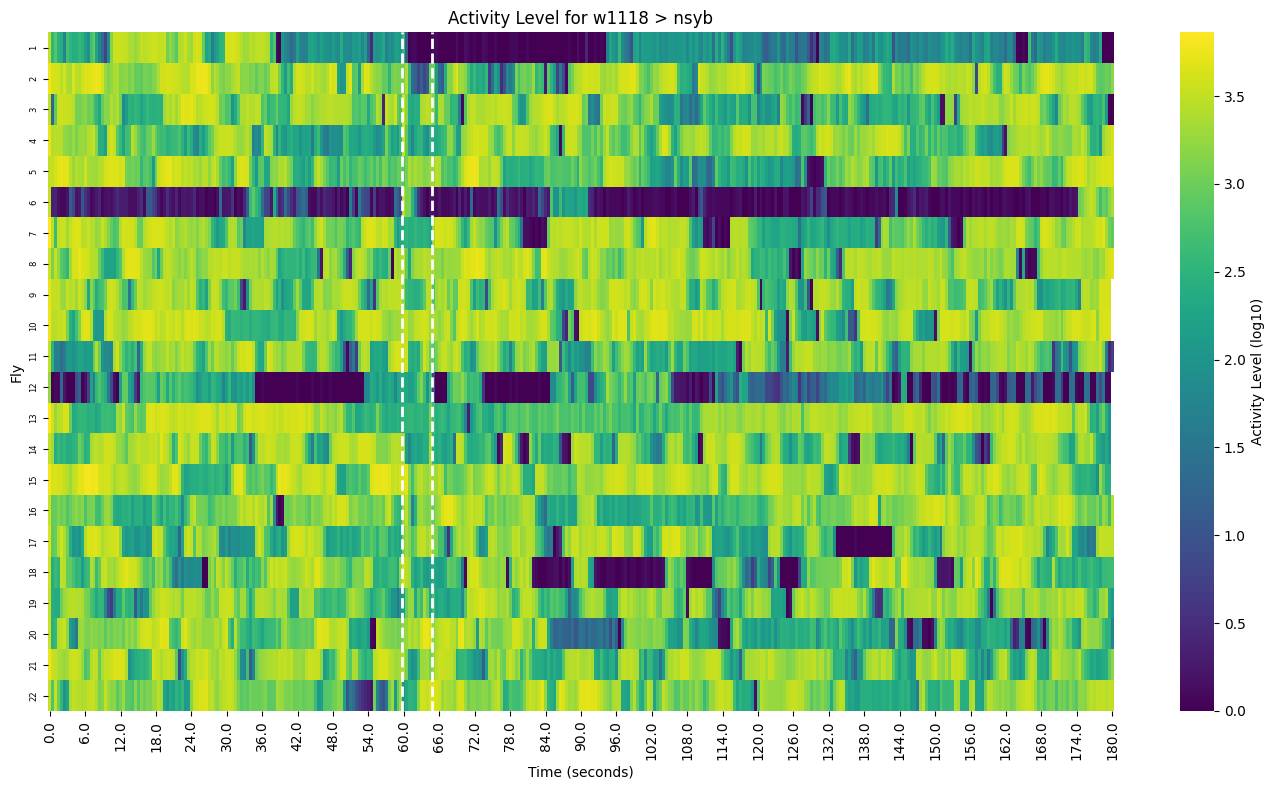

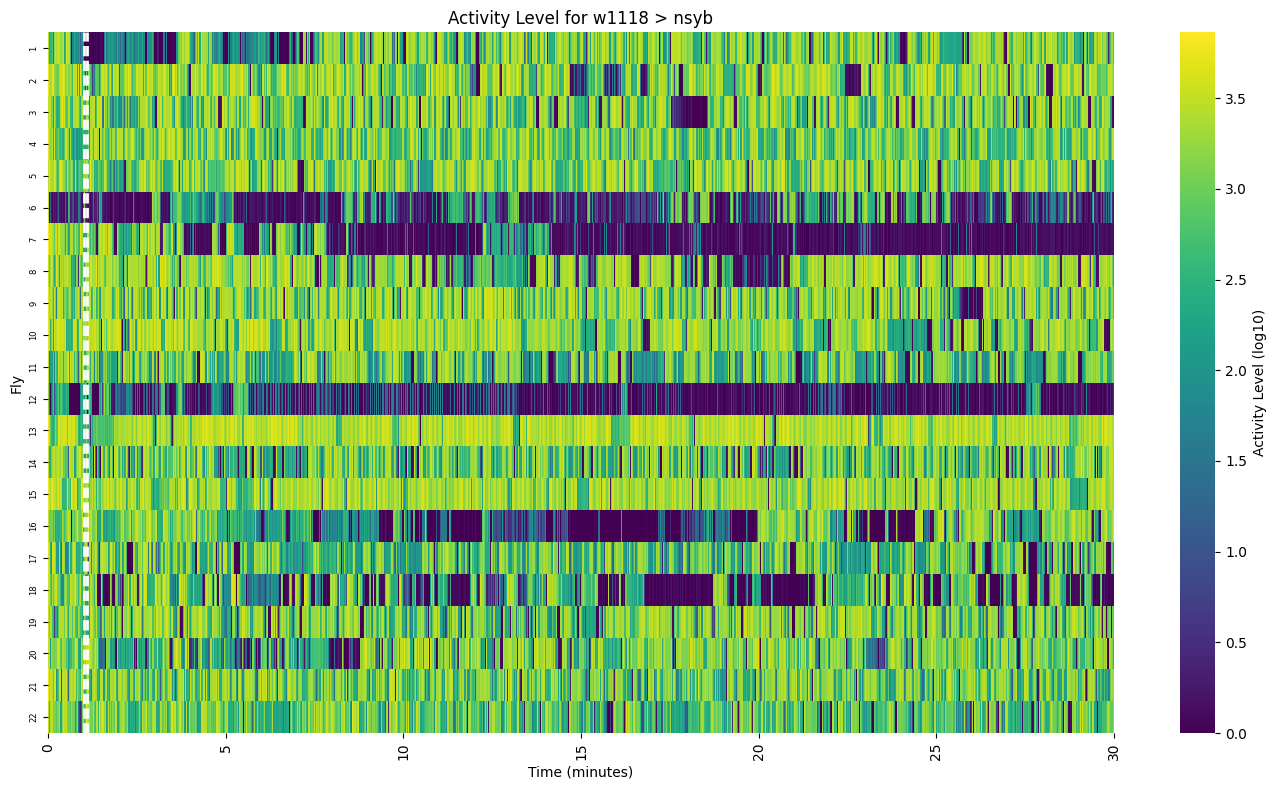

In [111]:
# Generates activity heatmaps for a given cross, with Timestamp resampled to 0.5s intervals and log scale applied
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re

# -----------------------------
# USER INPUT
# -----------------------------
cross_folder_name = "w1118_nsyb_csv"

base_path = "C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3"
folder_path = os.path.join(base_path, cross_folder_name)

output_dir = "C:\\Users\\Leif_D\\Documents\\trumelan data\\eopn3\\20251111 figures\\heatmaps"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Helpers (same ergonomic logic as line graphs)
# -----------------------------
def pretty_component(name: str) -> str:
    mapping = {
        "ok371": "OK371-Gal4",
        "wtchrmine": "WtChRmine",
        "cschrimson": "CsChrimson",
        "nanchung": "Nanchung-Gal4",
        "wtchr": "WtChRmine",
        "gtccr4": "GtCCR4",
        "cha" : "ChAT-Gal4",
        "elav": "Elav-Gal4",
        "eopn3": "AsOPN3",
        "acr": "GtACR1",
    }
    key = name.strip().lower()
    return mapping.get(key, name.strip())

def parse_cross_components(cross_name: str):
    """
    From a name like:
      - 'OK371 x GtCCR4 (EL)'
      - 'ok371_gtccr4_el'   (if you later change style)
    return a list of pretty components, e.g. ['OK371-Gal4', 'GtCCR4 (EL)'].
    """
    s = cross_name.strip()

    # Prefer explicit 'x' separator if present
    if re.search(r'\bx\b', s, flags=re.IGNORECASE):
        parts = re.split(r'\bx\b', s, flags=re.IGNORECASE)
        parts = [p.strip() for p in parts if p.strip()]
    else:
        # fallback: underscores / spaces
        s = s.replace('_', ' ')
        parts = [p.strip() for p in s.split() if p.strip()]

    pretty_parts = []
    for p in parts:
        # If it has parentheses like "GtCCR4 (EL)", split base + suffix
        if "(" in p and ")" in p:
            base = p.split("(")[0].strip()
            suffix = p[p.find("("):].strip()
            pretty_parts.append(pretty_component(base) + " " + suffix)
        else:
            pretty_parts.append(pretty_component(p))
    return pretty_parts

components = parse_cross_components(cross_folder_name)
if len(components) >= 2:
    cross_label = f"{components[0]} > {components[1]}"
    base_name = f"{components[0]} x {components[1]}"
else:
    cross_label = components[0]
    base_name = components[0]

# Chart title derived from cross name
title_name = f"Activity Level for {cross_label}"

# -----------------------------
# LOAD & PREPROCESS DATA ONCE
# -----------------------------
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

data_list = []

# Load each fly's data, synchronize timestamps to start at 0s, and keep only Activity Level
for i, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file, usecols=["Timestamp (ms)", "Activity Level"])
    # Convert Timestamp to seconds and start at 0
    df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000
    df = df.set_index("Time (s)")
    df = df[["Activity Level"]]  # keep only activity
    df.rename(columns={"Activity Level": f"{i}"}, inplace=True)
    data_list.append(df)

# Combine all flies into one dataframe (full recording)
all_data = pd.concat(data_list, axis=1)

# Common resampling bin size
bin_size = 0.5  # seconds

# -----------------------------
# HEATMAP 1: 0–180 s (seconds on x-axis)
# -----------------------------
all_data_180 = all_data[all_data.index <= 180]

all_data_resampled_180 = all_data_180.groupby((all_data_180.index // bin_size) * bin_size).mean()

# Log transform (avoid log(0))
all_data_log_180 = np.log10(all_data_resampled_180 + 1)

# Transpose for heatmap: rows = flies, columns = time bins
heatmap_data_180 = all_data_log_180.T

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data_180,
    cmap="viridis",
    cbar_kws={'label': 'Activity Level (log10)'},
    xticklabels=12,  # show every 12th label to reduce clutter
    yticklabels=True
)

# Set y-axis tick font size (flies)
plt.yticks(fontsize=6)

# Demarcates illumination period with dashed white vertical lines
illum_start, illum_end = 60, 65  # seconds
illum_start_idx = int(illum_start // bin_size)
illum_end_idx = int(illum_end // bin_size)
plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

plt.xlabel("Time (seconds)")
plt.ylabel("Fly")
plt.title(title_name)
plt.tight_layout()

output_path_img_180 = os.path.join(output_dir, f"{base_name} heatmap_180s.svg")
plt.savefig(output_path_img_180)
plt.show()

# -----------------------------
# HEATMAP 2: 0–1800 s (x-axis shown in minutes)
# -----------------------------
all_data_1800 = all_data[all_data.index <= 1800]

all_data_resampled_1800 = all_data_1800.groupby((all_data_1800.index // bin_size) * bin_size).mean()

# Log transform
all_data_log_1800 = np.log10(all_data_resampled_1800 + 1)

# Transpose for heatmap: rows = flies, columns = time bins
heatmap_data_1800 = all_data_log_1800.T

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data_1800,
    cmap="viridis",
    cbar_kws={'label': 'Activity Level (log10)'},
    xticklabels=12,  # same aesthetic density
    yticklabels=True
)

# Set y-axis tick font size (flies)
plt.yticks(fontsize=6)

# Illumination lines still at 60–65 seconds
illum_start_idx = int(illum_start // bin_size)
illum_end_idx = int(illum_end // bin_size)
plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

# Express x-axis in minutes while bins remain in seconds internally
# 0–1800 s → 0–30 min. Put ticks every 5 min for readability.
max_seconds = 1800
minutes_ticks = np.arange(0, 31, 5)  # 0, 5, 10, ..., 30
tick_positions = (minutes_ticks * 60) / bin_size  # position in bin indices
plt.xticks(tick_positions, [str(m) for m in minutes_ticks])

plt.xlabel("Time (minutes)")
plt.ylabel("Fly")
plt.title(title_name)
plt.tight_layout()

output_path_img_1800 = os.path.join(output_dir, f"{base_name} heatmap_30min.svg")
plt.savefig(output_path_img_1800)
plt.show()
